In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Aprendizaje supervisado parte 2 -- Regresión

En regresión intentamos predecir una variable continua de salida -- al contrario que las variables nominales que predecíamos en los ejemplos anteriores de clasificación.

Vamos a empezar con un ejemplo simple de juguete con una sola dimensión de entrada (variable explicativa) y una variable objetivo. Crearemos un dataset mediante una curva sinusoidal con algo de ruido:

In [3]:
x = np.linspace(-3, 3, 100)
print(x)
print(x.shape)

[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576 -2.6969697
 -2.63636364 -2.57575758 -2.51515152 -2.45454545 -2.39393939 -2.33333333
 -2.27272727 -2.21212121 -2.15151515 -2.09090909 -2.03030303 -1.96969697
 -1.90909091 -1.84848485 -1.78787879 -1.72727273 -1.66666667 -1.60606061
 -1.54545455 -1.48484848 -1.42424242 -1.36363636 -1.3030303  -1.24242424
 -1.18181818 -1.12121212 -1.06060606 -1.         -0.93939394 -0.87878788
 -0.81818182 -0.75757576 -0.6969697  -0.63636364 -0.57575758 -0.51515152
 -0.45454545 -0.39393939 -0.33333333 -0.27272727 -0.21212121 -0.15151515
 -0.09090909 -0.03030303  0.03030303  0.09090909  0.15151515  0.21212121
  0.27272727  0.33333333  0.39393939  0.45454545  0.51515152  0.57575758
  0.63636364  0.6969697   0.75757576  0.81818182  0.87878788  0.93939394
  1.          1.06060606  1.12121212  1.18181818  1.24242424  1.3030303
  1.36363636  1.42424242  1.48484848  1.54545455  1.60606061  1.66666667
  1.72727273  1.78787879  1.84848485  1.90909091  1.9

In [4]:
rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.uniform(size=len(x))
print(y)
print(y.shape)  

[-2.08888696 -1.26522393 -1.27876477 -1.257685   -1.6021601  -1.56246646
 -1.67788501 -0.93995725 -1.32019251 -1.36313841 -2.22294822 -1.45474072
 -1.76798534 -2.54470161 -2.69996037 -2.78041759 -2.6905667  -2.44463288
 -2.45356039 -2.45328945 -1.9392768  -2.17361031 -1.74867325 -1.38028857
 -0.98819094 -0.36261351 -0.6713562  -0.11238917  0.16709517 -0.22889529
  0.42561591  0.02353616 -0.10397021  0.70568803  0.60399931  0.29454063
 -0.38280894 -0.77096368 -0.35912081 -0.75766206 -1.19740211 -0.90239699
 -1.38971288 -0.48460668 -1.04649125 -0.49725198 -0.6506897  -0.20108124
  0.10012603  0.0336359   1.12080318  1.22171707  1.6606482   1.85722813
  1.75767424  2.22714547  1.48241959  1.62008427  1.44280119  1.64477068
  1.58649184  1.31470287  1.6973733   1.04417604  0.79479123  0.90432881
  0.38412173  0.97121878  0.2215386   1.16881588  1.04759047  0.62403508
  0.63214572  1.68649141  1.85464681  2.1732681   2.51792076  2.11486255
  2.6715699   2.66699876  3.60762202  3.50880354  3

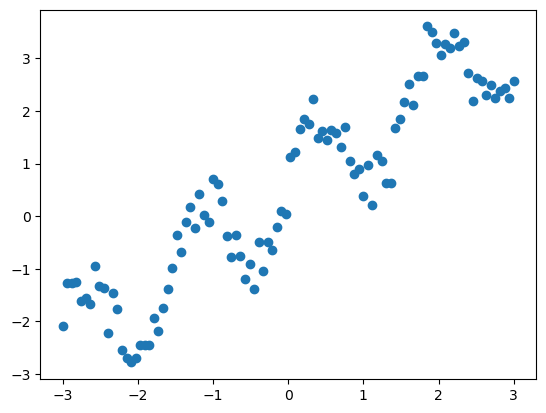

In [5]:
plt.plot(x, y, 'o');

Regresión lineal
=================

El primer modelo que vamos a introducir es el llamado regresión lineal simple, que simplemente predice que los datos caen en una línea recta. Una forma de ajustar este modelo es usar `LinearRegression` (también conocido como regresión [*Ordinary Least Squares (OLS)*](https://en.wikipedia.org/wiki/Ordinary_least_squares)).
La interfaz para LinearRegression es exactamente la misma que para los clasificadores explorados anteriormente, con la salvedad de que ahora $y$ contiene valores reales, en lugar de valores categóricos.

Como recordaremos, el API de scikit-learn requiere que le pasemos la variable objetivo ($y$) como un array de 1 dimensión; el API de scikit-learn espera que los ejemplos ($\mathbf{X}$) vengan en forma de un array de dos dimensiones (aunque solo haya una columna o característica). Por tanto, debemos convertir el array NumPy $x$ de una dimensión a una matriz $\mathbf{X}$ con dos ejes:


In [8]:
print('Antes: ', x.shape)
print(x)
X = x[:, np.newaxis]
print('Después: ', X.shape)
print(X)

Antes:  (100,)
[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576 -2.6969697
 -2.63636364 -2.57575758 -2.51515152 -2.45454545 -2.39393939 -2.33333333
 -2.27272727 -2.21212121 -2.15151515 -2.09090909 -2.03030303 -1.96969697
 -1.90909091 -1.84848485 -1.78787879 -1.72727273 -1.66666667 -1.60606061
 -1.54545455 -1.48484848 -1.42424242 -1.36363636 -1.3030303  -1.24242424
 -1.18181818 -1.12121212 -1.06060606 -1.         -0.93939394 -0.87878788
 -0.81818182 -0.75757576 -0.6969697  -0.63636364 -0.57575758 -0.51515152
 -0.45454545 -0.39393939 -0.33333333 -0.27272727 -0.21212121 -0.15151515
 -0.09090909 -0.03030303  0.03030303  0.09090909  0.15151515  0.21212121
  0.27272727  0.33333333  0.39393939  0.45454545  0.51515152  0.57575758
  0.63636364  0.6969697   0.75757576  0.81818182  0.87878788  0.93939394
  1.          1.06060606  1.12121212  1.18181818  1.24242424  1.3030303
  1.36363636  1.42424242  1.48484848  1.54545455  1.60606061  1.66666667
  1.72727273  1.78787879  1.84848485  

De nuevo dividimos nuestro dataset en entrenamiento (75%) y test (25%):

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Ahora usamos el algoritmo `LinearRegression` para **ajustar un modelo de regresión a los datos de entrenamiento**:

In [12]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(n_jobs=2)
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",2
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Después del ajuste, podemos observar los parámetros obtenidos.

In [13]:
print('Pesos: ', regressor.coef_)
print('Ordenada en el origen: ', regressor.intercept_)

Pesos:  [0.90211711]
Ordenada en el origen:  0.44840974988267995


Ya que nuestro modelo de regresión es lineal, la relación entre la variable objetivo ($y$) y la variable independiente ($x$) se define como:

$$y = peso \times x + \text{ordenadaOrigen}$$

Para representar el modelo, introducimos los valores máximo y mínimo de $x$ en esta ecuación.

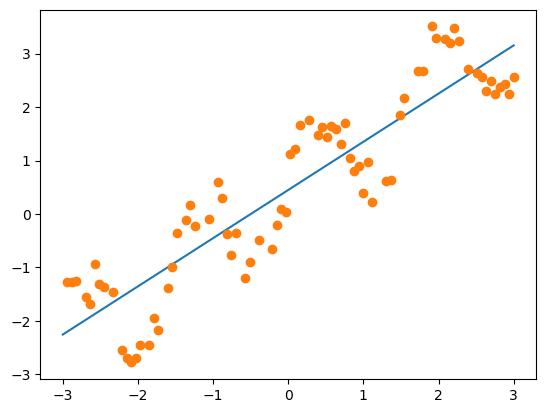

In [14]:
min_pt = X.min() * regressor.coef_[0] + regressor.intercept_
max_pt = X.max() * regressor.coef_[0] + regressor.intercept_

plt.plot([X.min(), X.max()], [min_pt, max_pt])
plt.plot(X_train, y_train, 'o');

De la misma forma que con los estimadores de clasificación, utilizamos el método `predict` para obtener valores estimados de la variable objetivo. Y esperamos que esos valores caigan en la línea anterior:

In [15]:
y_pred_train = regressor.predict(X_train)

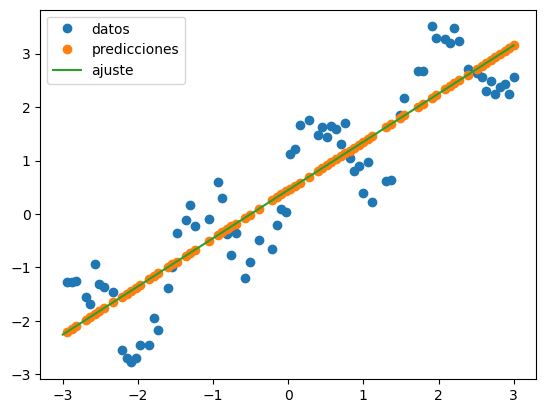

In [16]:
plt.plot(X_train, y_train, 'o', label="datos")
plt.plot(X_train, y_pred_train, 'o', label="predicciones")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label='ajuste')
plt.legend(loc='best')

Como podemos ver en el gráfico, la línea es capaz de capturar la pendiente general de los datos, pero no muchos detalles.

Ahora vamos a probar con el conjunto de test:

In [17]:
y_pred_test = regressor.predict(X_test)

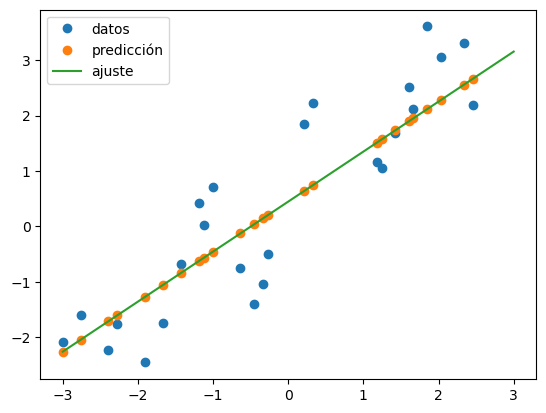

In [18]:
plt.plot(X_test, y_test, 'o', label="datos")
plt.plot(X_test, y_pred_test, 'o', label="predicción")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label='ajuste')
plt.legend(loc='best');

De nuevo, scikit-learn proporciona un método fácil para evaluar cuantitativamente los estimadores de regresión a través de la función ``score``. Para tareas de regresión, este sería por defecto el R<sup>2</sup>. Otra forma popular de evaluación sería el *Mean Squared Error* (MSE). Como indica su nombre, el MSE consiste simplemente en la diferencia al cuadrado promediada entre los valores predichos y los valores reales:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (\text{predicted}_i - \text{true}_i)^2$$

In [19]:
regressor.score(X_test, y_test)

0.7994321405079685

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Añade una característica que consista en `sin(4x)` a la matriz `X` y vuelve a ajustar el modelo. Visualiza las predicciones con este modelo más complejo, aunque aún lineal.
      </li>
    </ul>
</div>

(100,)


(100,)


Antes:  (100,)
[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576 -2.6969697
 -2.63636364 -2.57575758 -2.51515152 -2.45454545 -2.39393939 -2.33333333
 -2.27272727 -2.21212121 -2.15151515 -2.09090909 -2.03030303 -1.96969697
 -1.90909091 -1.84848485 -1.78787879 -1.72727273 -1.66666667 -1.60606061
 -1.54545455 -1.48484848 -1.42424242 -1.36363636 -1.3030303  -1.24242424
 -1.18181818 -1.12121212 -1.06060606 -1.         -0.93939394 -0.87878788
 -0.81818182 -0.75757576 -0.6969697  -0.63636364 -0.57575758 -0.51515152
 -0.45454545 -0.39393939 -0.33333333 -0.27272727 -0.21212121 -0.15151515
 -0.09090909 -0.03030303  0.03030303  0.09090909  0.15151515  0.21212121
  0.27272727  0.33333333  0.39393939  0.45454545  0.51515152  0.57575758
  0.63636364  0.6969697   0.75757576  0.81818182  0.87878788  0.93939394
  1.          1.06060606  1.12121212  1.18181818  1.24242424  1.3030303
  1.36363636  1.42424242  1.48484848  1.54545455  1.60606061  1.66666667
  1.72727273  1.7878

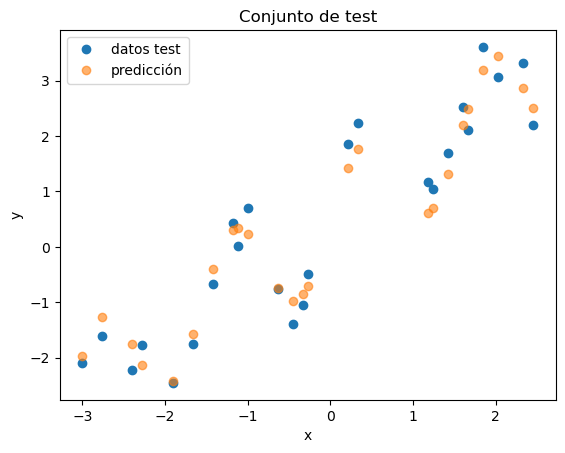

In [ ]:
x = np.linspace(-3, 3, 100)
print(x.shape)
print('\n')

rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.uniform(size=len(x))
print(y.shape)
print('\n')
  
print('Antes: ', x.shape)
print(x)
X = x[:, np.newaxis]
print('Después: ', X.shape)
print(X)
print('\n')

nueva_caracteristica = np.sin(4 * x)
print(nueva_caracteristica.shape)
print('\n')

X = np.column_stack([X, nueva_caracteristica])
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
regressor = LinearRegression(n_jobs=2)
regressor.fit(X_train, y_train)
print('Pesos: ', regressor.coef_)
print('Ordenada en el origen: ', regressor.intercept_)

# Predicciones
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

# Visualización - usamos solo la primera columna (x original) para el eje X

plt.plot(X_test[:, 0], y_test, 'o', label="datos test")
plt.plot(X_test[:, 0], y_pred_test, 'o', label="predicción", alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Conjunto de test')
plt.legend(loc='best')

print(f'\nR² en test: {regressor.score(X_test, y_test):.4f}')


KNeighborsRegression
=======================
Del mismo modo que para clasificación, podemos utilizar un método basado en vecinos para regresión. Podemos predecir directamente el valor de la variable objetivo del punto más cercano o podemos promediar varios de los puntos más cercanos. Los métodos basados en vecinos son más populares en clasificación que en regresión, pese a lo cual es un método sencillo que puede servir como *baseline*.

In [39]:
from sklearn.neighbors import KNeighborsRegressor

x = np.linspace(-3, 3, 100)

rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.uniform(size=len(x))
  
X = x[:, np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)



kneighbor_regression = KNeighborsRegressor(n_neighbors=1)
kneighbor_regression.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


De nuevo, vamos a comprobar como se comporta en entrenamiento y en test:

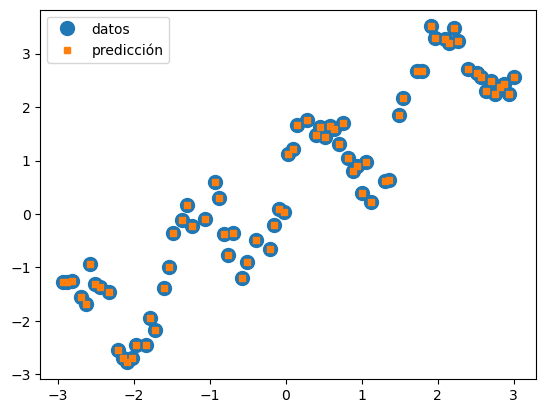

In [40]:
y_pred_train = kneighbor_regression.predict(X_train)

plt.plot(X_train, y_train, 'o', label="datos", markersize=10)
plt.plot(X_train, y_pred_train, 's', label="predicción", markersize=4)
plt.legend(loc='best');

En entrenamiento, la predicción es perfecta, ya que cada ejemplo es su vecino más cercano.

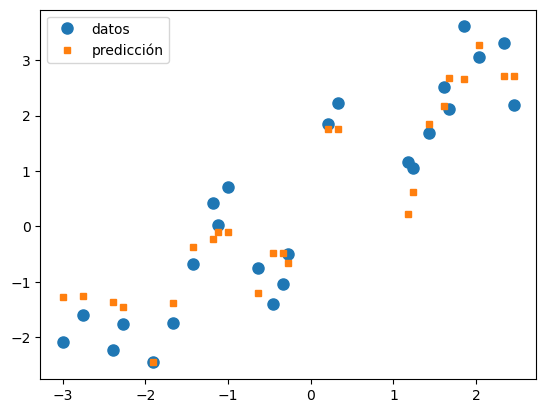

In [41]:
y_pred_test = kneighbor_regression.predict(X_test)

plt.plot(X_test, y_test, 'o', label="datos", markersize=8)
plt.plot(X_test, y_pred_test, 's', label="predicción", markersize=4)
plt.legend(loc='best');

En el conjunto de test, capturamos mejor la variación de los datos que con el modelo lineal, aunque nuestro estimador haga algunas cosas *un poco raras*. Evaluemos la puntuación R<sup>2</sup>:

In [42]:
kneighbor_regression.score(X_test, y_test)

0.9130936474325438

Es mucho mejor que antes. El problema era que un modelo lineal no era un ajuste adecuado para el problema, ya que no tenía la suficiente complejidad e infra-entrenaba los datos (error alto por sesgo).

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Compara KNeighborsRegressor y LinearRegression en el dataset boston housing. Puedes cargar el dataset utilizando ``sklearn.datasets.load_boston``. Puedes saber más de este dataset observando el atributo ``DESCR`` del objeto resultante.
      </li>
    </ul>
</div>